<a href="https://colab.research.google.com/github/izDeLaMo/carisurg-portfolio/blob/main/Week_0_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CariSurg MedTech Pathways — Week 0, Assignment 2


## 1. Load data




In [36]:
# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Carisurg/Copy of EmergencyTriageDataset_Reduced_Dirty.csv'
#For manual upload
#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

df = pd.read_csv(FILE_PATH)

# Re-apply Gender cleaning from Day 1 so we start from a consistent state
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset: 2205 rows x 11 columns


In [38]:
# The five most useful inspection commands — run them in order, every time
print("=== head() — first 5 rows ===")
print(df.head())

=== head() — first 5 rows ===
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [39]:
print("=== tail() — last 5 rows (catches truncation issues) ===")
print(df.tail())

=== tail() — last 5 rows (catches truncation issues) ===
        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  2383   65       1  15.0  140   80.0  100.00   85.0  36.4  16.0  21.0
2204  2384   78       0  15.0  145   90.0  108.33   75.0  37.6  20.0  21.0


In [40]:
print("=== describe() — statistics for numeric columns only ===")
print(df.describe())

=== describe() — statistics for numeric columns only ===
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000    30.000000    39.330000   
25%     577.000000    50.000000     0.000000    70.000000    82.500000   
50%    1135.000000    64.000000     1.000000    78.000000    93.330000   
75%    1703.000000    77.000000     1.000000    87.000000   103.330000   
max    2384.000000    98.000000     1.000000   173.000000   185.000000   

                RR         Fio2  
count  2183.000000  2183.000000  
mean     20.262254    25.019698  
std       5.742333    10.144288  
min      12.000000    21.000000  
25%      17.000000    21.000000  
50%      18.000000    21.000000  
75%      21.000000    21.000000  
max 

In [41]:
print("=== info() — column types and non-null counts ===")
df.info()

=== info() — column types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB


In [42]:
print("=== shape — (rows, columns) ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

=== shape — (rows, columns) ===
Rows: 2205, Columns: 11


In [43]:
# The five most useful inspection commands — run them in order, every time
print("=== head() — first 5 rows ===")
print(df.head())

=== head() — first 5 rows ===
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [44]:
print("=== tail() — last 5 rows (catches truncation issues) ===")
print(df.tail())

=== tail() — last 5 rows (catches truncation issues) ===
        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  2383   65       1  15.0  140   80.0  100.00   85.0  36.4  16.0  21.0
2204  2384   78       0  15.0  145   90.0  108.33   75.0  37.6  20.0  21.0


In [45]:
print("=== info() — column types and non-null counts ===")
df.info()

=== info() — column types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB


In [46]:
print("=== describe() — statistics for numeric columns only ===")
print(df.describe())

=== describe() — statistics for numeric columns only ===
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000    30.000000    39.330000   
25%     577.000000    50.000000     0.000000    70.000000    82.500000   
50%    1135.000000    64.000000     1.000000    78.000000    93.330000   
75%    1703.000000    77.000000     1.000000    87.000000   103.330000   
max    2384.000000    98.000000     1.000000   173.000000   185.000000   

                RR         Fio2  
count  2183.000000  2183.000000  
mean     20.262254    25.019698  
std       5.742333    10.144288  
min      12.000000    21.000000  
25%      17.000000    21.000000  
50%      18.000000    21.000000  
75%      21.000000    21.000000  
max 

In [47]:
df.sample(10)

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
1013,1044,28,1,15.0,120,90.0,100.00,95.0,36.0,18.0,21.0
1117,1150,70,1,15.0,122,74.0,90.00,72.0,37.0,18.0,21.0
113,125,64,1,15.0,100,71.0,80.67,85.0,36.7,18.0,21.0
561,587,85,1,14.0,150,70.0,96.67,72.0,37.0,34.0,40.0
188,203,69,0,15.0,115,70.0,85.00,78.0,37.0,19.0,21.0
486,508,63,1,15.0,130,90.0,103.33,76.0,36.0,16.0,21.0
111,123,54,1,13.0,500,80.0,96.67,95.0,37.0,16.0,21.0
1612,1660,47,1,15.0,125,85.0,98.33,116.0,37.0,19.0,21.0
349,369,74,0,15.0,91,57.0,68.33,80.0,38.0,28.0,21.0
616,642,85,0,15.0,122,94.0,103.33,300.0,36.1,19.0,21.0


## 1.GCS

In [48]:
# GCS is currently stored as a string (object type)
print("GCS dtype:", df['GCS'].dtype)
print("Unique GCS values:", df['GCS'].unique())

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']


In [49]:
# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')

print("After conversion:")
print(f"  dtype: {df['GCS'].dtype}")
print(f"  NaN count: {df['GCS'].isnull().sum()}")
print(f"  Range: {df['GCS'].min()} to {df['GCS'].max()}")

After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0


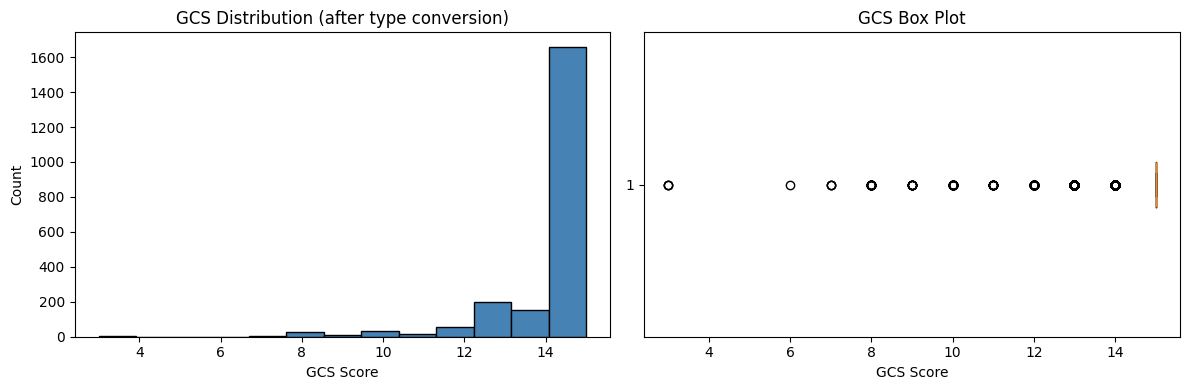

Plot saved as gcs_distribution.png


In [50]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['GCS'].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('GCS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('GCS Distribution (after type conversion)')

axes[1].boxplot(df['GCS'].dropna(), vert=False)
axes[1].set_xlabel('GCS Score')
axes[1].set_title('GCS Box Plot')

plt.tight_layout()
plt.savefig('gcs_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as gcs_distribution.png")

In [51]:
invalid_gcs = df[(df['GCS'] < 3) | (df['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))

GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []


In [52]:
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df['GCS'].isnull().sum()}")

NaN count after range filter: 44


In [53]:
# Compute the median and use it to fill NaN values
gcs_median = df['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df['GCS'] = df['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df['GCS'].describe())
print(f"Remaining NaNs: {df['GCS'].isnull().sum()}")

GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


## 2. SBP

In [54]:
print("SBP unique values (sample):", df['SBP'].unique()[:15])
print("SBP dtype:", df['SBP'].dtype)

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [55]:
# 1. Convert to numeric — non-numeric entries become NaN
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
print("After type conversion:")
print(df['SBP'].describe())

After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


Due the the wide range of values in the graph i used a ranges of 10 do that the data would be readable





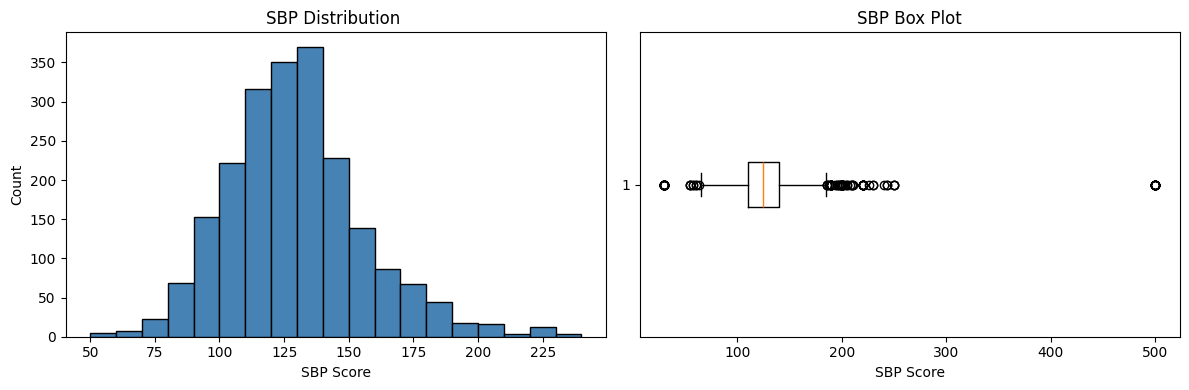

In [56]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = range(50, 250, 10)
axes[0].hist(df['SBP'].dropna(), bins=bins, edgecolor='black', color='steelblue')
axes[0].set_xlabel('SBP Score')
axes[0].set_ylabel('Count')
axes[0].set_title('SBP Distribution ')

axes[1].boxplot(df['SBP'].dropna(), vert=False)
axes[1].set_xlabel('SBP Score')
axes[1].set_title('SBP Box Plot')

plt.tight_layout()
plt.savefig('SBP_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [57]:
invalid_sbp = df[(df['SBP'] < 50) | (df['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())

Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0


In [58]:
# 3. Replace out-of-range with NaN, then impute with median
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df['SBP'].median()
df['SBP'] = df['SBP'].fillna(sbp_median)

print(f"SBP median (before imputation): {sbp_median}")

print(f"SBP after cleaning: min={df['SBP'].min()}, max={df['SBP'].max()}, NaNs={df['SBP'].isnull().sum()}")

SBP median (before imputation): 125.0
SBP after cleaning: min=55.0, max=250.0, NaNs=0


## 3. Temperature

In [59]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df['Temp'].unique()[:20])

Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']


In [60]:
# 1. Convert to numeric — non-numeric entries become NaN
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
print("After type conversion:")
print(df['Temp'].describe())

After type conversion:
count    2157.000000
mean       37.340566
std         1.328983
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


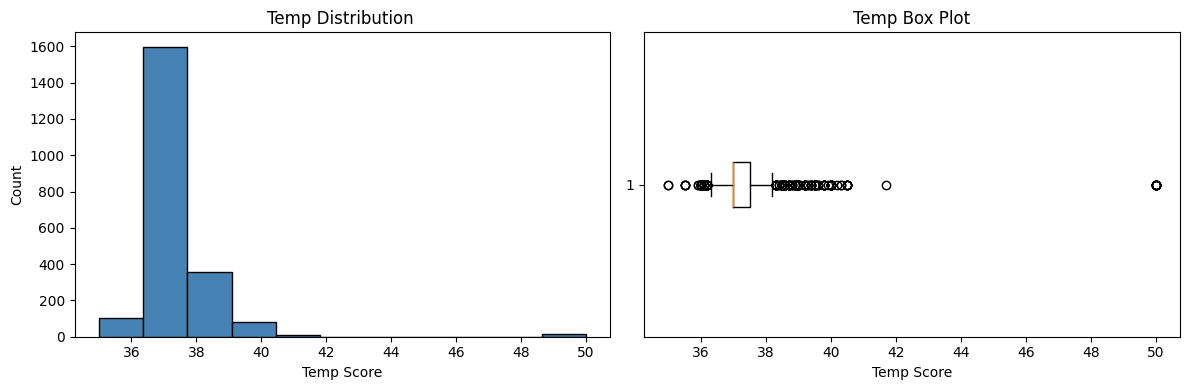

In [61]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Temp'].dropna(), bins=11, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Temp Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Temp Distribution ')

axes[1].boxplot(df['Temp'].dropna(), vert=False)
axes[1].set_xlabel('Temp Score')
axes[1].set_title('Temp Box Plot')

plt.tight_layout()
plt.savefig('Temp_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [62]:
# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return np.nan                           # anything else -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].describe())

After standardisation:
count    2157.000000
mean       37.340566
std         1.328983
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [63]:
# Apply range filter: valid body temperature 32–43°C
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan

# Impute with median
temp_median = round(df['Temp'].median(), 1)
df['Temp'] = df['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df['Temp'].min():.1f}, max={df['Temp'].max():.1f}, NaNs={df['Temp'].isnull().sum()}")

Temp after cleaning: min=35.0, max=41.7, NaNs=0


## 4. Pulse

In [64]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df['pulse'].unique()[:40])
print(f"Dtype: {df['pulse'].dtype}")

Temp unique values (sample):
['128.0' '80.0' '92.0' '100.0' '85.0' '99.0' '78.0' '130.0' '63.0' '98.0'
 '76.0' '166.0' '151.0' '94.0' '87.0' '75.0' '88.0' '108.0' '112.0'
 '125.0' '65.0' '90.0' '300.0' '72.0' '58.0' '140.0' '105.0' '110.0'
 'error' '97.0' '82.0' '84.0' '86.0' '56.0' '70.0' '69.0' '120.0' '111.0'
 '156.0' '60.0']
Dtype: object


1) Inspect (unique(), value_counts(), describe())

In [65]:
print(df['pulse'].describe())

count     2183
unique     116
top       80.0
freq       161
Name: pulse, dtype: object


2) Understand the clinical meaning and valid range

The valid range for pulse values are 	20–250 bpm and the normal ranges for resting adult are 60–100 (possible reason for skew)

3. Convert type with pd.to_numeric(..., errors='coerce')

In [66]:
# 1. Convert to numeric — non-numeric entries become NaN
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
print("After type conversion:")
print(df['pulse'].describe())
print(f"Pulse before cleaning: min={df['pulse'].min():.1f}, max={df['pulse'].max():.1f}, NaNs={df['pulse'].isnull().sum()}")

After type conversion:
count    2161.000000
mean       96.094863
std        31.035460
min         0.000000
25%        80.000000
50%        90.000000
75%       108.000000
max       300.000000
Name: pulse, dtype: float64
Pulse before cleaning: min=0.0, max=300.0, NaNs=44


*Due the the wide range of values in the graph i used a ranges of 10 do that the data would be readable*





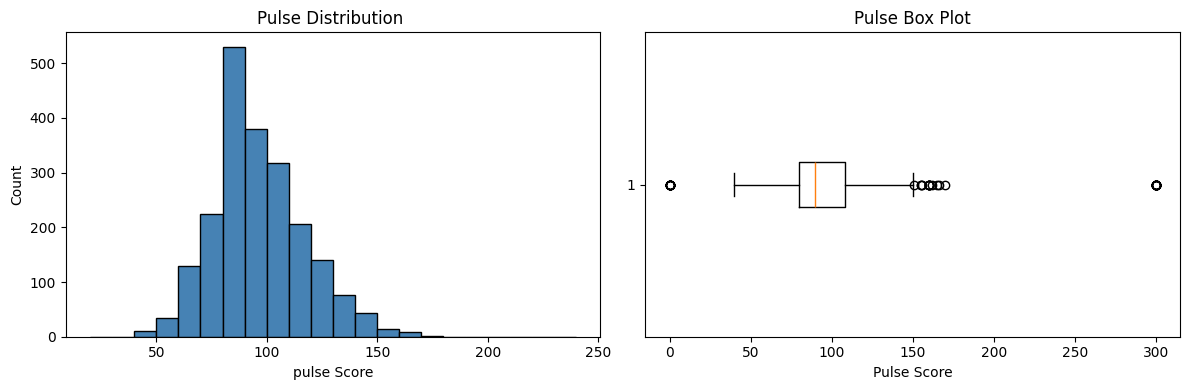

In [67]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = range(20, 250, 10)
# range for bins created to have better visualization
axes[0].hist(df['pulse'].dropna(), bins=bins, edgecolor='black', color='steelblue')
axes[0].set_xlabel('pulse Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Pulse Distribution ')

axes[1].boxplot(df['pulse'].dropna(), vert=False)
axes[1].set_xlabel('Pulse Score')
axes[1].set_title('Pulse Box Plot')

plt.tight_layout()
plt.savefig('pulse_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [68]:
# 2. Identify out-of-range values
invalid_pulse = df[(df['pulse'] < 50) | (df['pulse'] > 250)]
print(f"Out-of-range Pulse rows: {len(invalid_pulse)}")
print(invalid_pulse[['ID', 'pulse']].head())

Out-of-range Pulse rows: 53
      ID  pulse
36    39  300.0
105  117    0.0
109  121    0.0
120  132    0.0
125  137   41.0


4. Flag and replace out-of-range values with NaN

In [69]:
df.loc[(df['pulse'] < 50) | (df['pulse'] > 250)] = np.nan


In [70]:
# Justification: Due to the data being left skewed and contains outliers we chose the median imputation strategy
# Compute the median and use it to fill NaN values
pulse_median = round(df['pulse'].median(), 1)

df['pulse'] = df['pulse'].fillna(pulse_median)

print(f"Pulse median (before imputation): {pulse_median}")
print(df['pulse'].describe())
print(f"Pulse after cleaning: min={df['pulse'].min():.1f}, max={df['pulse'].max():.1f}, NaNs={df['pulse'].isnull().sum()}")

Pulse median (before imputation): 90.0
count    2205.000000
mean       94.531519
std        19.600653
min        50.000000
25%        81.000000
50%        90.000000
75%       106.000000
max       170.000000
Name: pulse, dtype: float64
Pulse after cleaning: min=50.0, max=170.0, NaNs=0


# CariSurg MedTech Pathways — Week 0, Assignment 3


## 1. Setup — Load and Clean

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'


# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 2311


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1.0,34.0,NaN,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2.0,20.0,NaN,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3.0,77.0,NaN,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4.0,23.0,NaN,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5.0,86.0,NaN,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


## Visualization

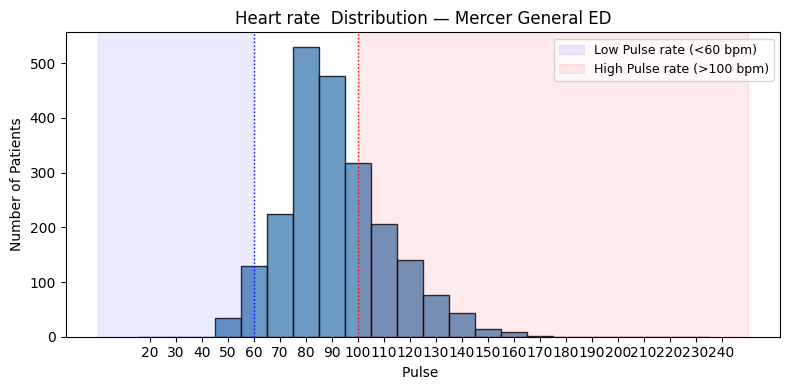

Saved: pulse_histogram.png


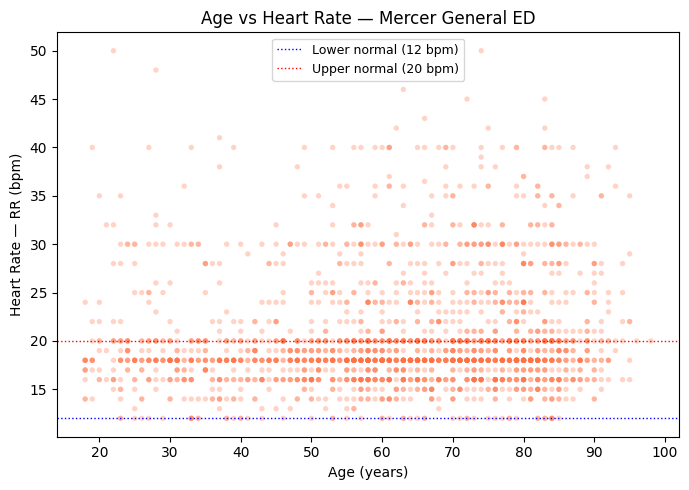

Saved: age_vs_RR.png


In [72]:
# ── YOUR TURN ────────────────────────────────────────────────
# Pick any two variables from the dataset and create a meaningful plot.
# Before you code, answer these questions in a comment:
#
# 1. What is the clinical question this plot answers?
# 2. What type of plot is appropriate (histogram, scatter, bar, box)?
# 3. What reference lines or annotations would add clinical meaning?

# Your code here:
# 1. Clinical question:
# Does the patient pulse distribution show abnormal heart rate ranges,
# and is there any relationship between patient age and respiratory rate (RR)?

# 2. Appropriate plots:
# Histogram for pulse distribution and scatter plot for Age vs RR relationship.

# 3. Clinical reference lines/annotations:
# Normal pulse range markers at 60 and 100 bpm,
# and normal respiratory rate markers at 12 and 20 bpm.

# Histogram: pulse distribution
fig, ax = plt.subplots(figsize=(8, 4))
bins=range(20, 250, 10)
ax.hist(df['pulse'], bins=bins, edgecolor='black',
        color='steelblue', alpha=0.8, align='left')



ax.axvspan(0, 60, alpha=0.08, color='blue', label='Low Pulse rate (<60 bpm)')
ax.axvspan(100, 250, alpha=0.08, color='red', label='High Pulse rate (>100 bpm)')
ax.axvline(x=60, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=100, color='red', linestyle=':', linewidth=1)

ax.set_title('Heart rate  Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Pulse ')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(20, 250, 10))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pulse_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_histogram.png")

# Scatter plot: Age vs RR — does age affect resting heart rate in ED patients?
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['RR'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.set_title('Age vs Heart Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — RR (bpm)')

# Add clinical reference lines
ax.axhline(y=12, color='blue', linestyle=':', linewidth=1, label='Lower normal (12 bpm)')
ax.axhline(y=20, color='red', linestyle=':', linewidth=1, label='Upper normal (20 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_RR.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_RR.png")



# plt.savefig('my_plot.png', dpi=100, bbox_inches='tight')
# plt.show()